# Difference Explorer

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import mannwhitneyu
pd.set_option('display.max_columns', None)

INPUT_FILE_NAME_BERLIN = 'cases_Berlin-with-topics-and-agreement-scores-3EP-lawDraft-passedBills.csv'
INPUT_FILE_NAME_BRANDENBURG = 'cases_Brandenburg-with-topics-and-agreement-scores-preprocessed-3EP-lawDraft-passedBills.csv'
INPUT_FILE_NAME_BAWUE = 'cases_Baden-Württemberg-with-topics-and-agreement-scores-preprocessed-3EP-lawDraft-passedBills.csv'



def read_and_sanitize(file_name):
    df = pd.read_csv(file_name)
    print('Read', len(df), 'rows from', file_name)
    df = df.dropna(axis=1, how='all')  # drop all completely empty columns
    return df

df_berlin = read_and_sanitize(INPUT_FILE_NAME_BERLIN)
df_brandenburg = read_and_sanitize(INPUT_FILE_NAME_BRANDENBURG)
df_baWue = read_and_sanitize(INPUT_FILE_NAME_BAWUE)

Read 501 rows from cases_Berlin-with-topics-and-agreement-scores-3EP-lawDraft-passedBills.csv
Read 440 rows from cases_Brandenburg-with-topics-and-agreement-scores-preprocessed-3EP-lawDraft-passedBills.csv
Read 335 rows from cases_Baden-Württemberg-with-topics-and-agreement-scores-preprocessed-3EP-lawDraft-passedBills.csv


In [17]:
columns_to_exclude = ['case_id', '.delay', '.start', "start_time", ".count", "DokTyp", "VSys", "Vorgangs", "start_month", "start_weekday", "urheber_first_activity_"]
columns_to_include = [col for col in df_berlin.columns if not any(exclude in col for exclude in columns_to_exclude)]

#for col in columns_to_include:
#    print(col)

print(np.median(df_berlin['event_count']))
print("median duration:", np.median(df_berlin['duration']))

df_berlin[columns_to_include].describe(include='all')

7.0
median duration: 97.0


,event_count,duration,opposition_agreement_score,all_agreement_score,case:embedding,case:top_topics,case:top_topic,case:top_topic_similarity_score,case:government_agreement_score
count,501.000000,501.000000,501.000000,501.000000,501,501,501.000000,501.000000,501.000000
unique,NaN,NaN,NaN,NaN,501,501,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,[ 0.03242892 0.00095379 -0.02014885 ... -0.00...,"[(np.int64(18), np.float64(0.49446805951792644...",NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,1,1,NaN,NaN,NaN
mean,8.367265,134.510978,0.675316,0.500732,NaN,NaN,23.982036,0.427095,0.640386
std,7.964474,135.510097,0.324093,0.130952,NaN,NaN,10.193021,0.060334,0.310425
min,6.000000,15.000000,0.333333,0.400000,NaN,NaN,1.000000,0.275927,0.000000
25%,6.000000,58.000000,0.333333,0.400000,NaN,NaN,16.000000,0.382621,0.500000
50%,7.000000,97.000000,0.666667,0.466667,NaN,NaN,28.000000,0.424671,0.666667
75%,8.000000,163.000000,1.000000,0.533333,NaN,NaN,31.000000,0.465118,1.000000


In [18]:
columns_to_include = [col for col in df_brandenburg.columns if not any(exclude in col for exclude in columns_to_exclude)]
print("median duration:", np.median(df_brandenburg['duration']))

df_brandenburg[columns_to_include].describe(include='all')


median duration: 117.5


,event_count,duration,case:embedding,case:top_topics,case:top_topic,case:top_topic_similarity_score,case:government_agreement_score,case:opposition_agreement_score,case:all_agreement_score
count,440.00000,440.000000,440,440,440.000000,440.000000,440.000000,440.000000,440.000000
unique,NaN,NaN,440,440,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,[ 0.01363317 0.00542363 0.01304043 ... -0.00...,"[(np.int64(20), np.float64(0.46819136912582715...",NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
mean,10.72500,147.356818,NaN,NaN,24.759091,0.443654,0.559091,0.797727,0.438068
std,6.36758,114.067068,NaN,NaN,7.382560,0.050336,0.309175,0.321931,0.152698
min,4.00000,11.000000,NaN,NaN,2.000000,0.329744,0.000000,0.000000,0.333333
25%,7.00000,80.750000,NaN,NaN,20.000000,0.406262,0.500000,0.500000,0.333333
50%,9.00000,117.500000,NaN,NaN,29.000000,0.446571,0.500000,1.000000,0.416667
75%,12.00000,173.250000,NaN,NaN,29.000000,0.478372,1.000000,1.000000,0.500000


In [19]:
columns_to_include = [col for col in df_baWue.columns if not any(exclude in col for exclude in columns_to_exclude)]
print("median duration:", np.median(df_baWue['duration']))

df_baWue[columns_to_include].describe(include='all')


median duration: 69.0


,event_count,duration,opposition_agreement_score,all_agreement_score,case:embedding,case:top_topics,case:top_topic,case:top_topic_similarity_score,case:government_agreement_score
count,335.000000,335.000000,335.000000,335.000000,335,335,335.000000,335.000000,335.000000
unique,NaN,NaN,NaN,NaN,335,335,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,[ 0.01130723 0.02226111 -0.00226734 ... 0.01...,"[(np.int64(36), np.float64(0.42748913184908754...",NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,1,1,NaN,NaN,NaN
mean,8.185075,90.713433,0.615423,0.529552,NaN,NaN,24.973134,0.438439,0.586567
std,3.070297,101.527296,0.379460,0.196262,NaN,NaN,8.833245,0.057600,0.473835
min,4.000000,4.000000,0.000000,0.333333,NaN,NaN,3.000000,0.311330,0.000000
25%,6.000000,51.000000,0.333333,0.400000,NaN,NaN,17.000000,0.394051,0.000000
50%,7.000000,69.000000,0.500000,0.500000,NaN,NaN,29.000000,0.434965,1.000000
75%,9.000000,99.000000,1.000000,0.500000,NaN,NaN,29.000000,0.481653,1.000000


In [20]:
'''
for df in [df_berlin, df_brandenburg, df_baWue]:
    property = df['case:yearly_variants']
    print(f"{np.mean(property).round(2)} & {np.median(property).round(2)} & {np.std(property).round(2)}", end=" & ")
'''

'\nfor df in [df_berlin, df_brandenburg, df_baWue]:\n    property = df[\'case:yearly_variants\']\n    print(f"{np.mean(property).round(2)} & {np.median(property).round(2)} & {np.std(property).round(2)}", end=" & ")\n'

/var/folders/c0/znjbgdp95852r1d2gl38_cl40000gn/T/ipykernel_33883/3667068262.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='Region', y='duration', data=combined_df,


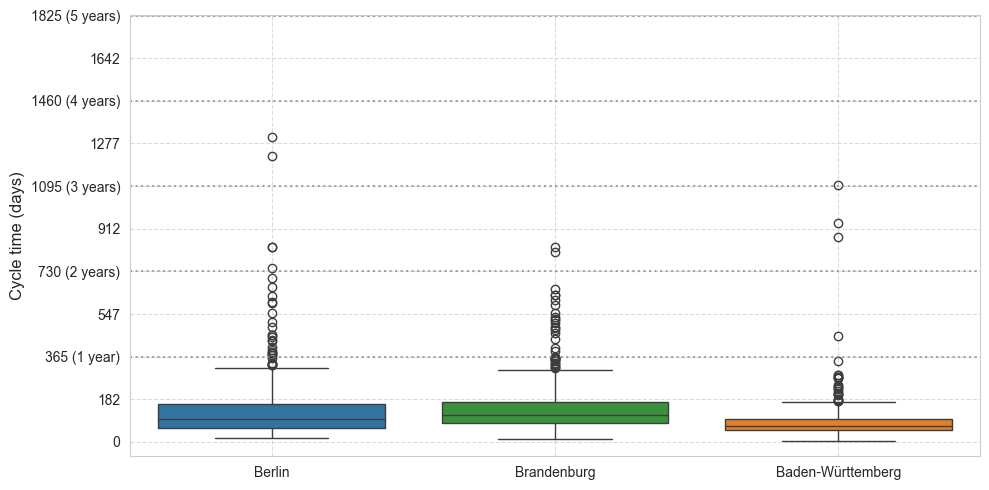

Mean durations:
Berlin: 134.5109780439122
Brandenburg: 147.35681818181817
Baden-Württemberg: 90.7134328358209


In [21]:
# Combine the data into a single DataFrame for plotting
df_berlin['Region'] = 'Berlin'
df_brandenburg['Region'] = 'Brandenburg'
df_baWue['Region'] = 'Baden-Württemberg'

combined_df = pd.concat([df_berlin[['duration', 'Region']], 
                         df_brandenburg[['duration', 'Region']], 
                         df_baWue[['duration', 'Region']]])

# Set a clean style
sns.set_style("whitegrid")
plt.figure(figsize=(10, 5))

# Create a color palette matching the one used in plot_fun_overall
# These are the default matplotlib colors
color_palette = {
    'Berlin': '#1f77b4',      # blue
    'Baden-Württemberg': '#ff7f0e', # orange
    'Brandenburg': '#2ca02c'  # green
}

# Create a simple but effective box plot
ax = sns.boxplot(x='Region', y='duration', data=combined_df,
                palette=color_palette)

# Explicitly set x-label to empty string
ax.set_xlabel('')
plt.ylabel('Cycle time (days)', fontsize=12)

# Add grid matching the other plot
plt.grid(True, linestyle='--', alpha=0.7)

# Add specific markings up to 5 years, with half-year intervals
days_in_year = 365
days_in_half_year = days_in_year / 2

# Create ticks at regular half-year intervals up to 5 years
half_year_ticks = [i * days_in_half_year for i in range(11)]  # 0 to 5 years in half-year steps

# Set y-axis ticks
ax.set_yticks(half_year_ticks)

# Create tick labels with year markers only for full years
def format_tick(x):
    years = x / days_in_year
    
    if years.is_integer():
        if years == 0:
            return "0"
        return f"{int(x)} ({int(years)} year{'s' if years > 1 else ''})"
    else:
        return str(int(x))

ax.set_yticklabels([format_tick(tick) for tick in half_year_ticks])

# Highlight the full year markers
for year in range(1, 6):  # Up to 5 years
    days = year * days_in_year
    plt.axhline(y=days, color='gray', linestyle=':', alpha=0.7)

# Ensure the plot is not cluttered
plt.tight_layout()
plt.savefig("cycleTime_boxplots.png", dpi=600)
plt.show()

print("Mean durations:")
print("Berlin:", df_berlin['duration'].mean())
print("Brandenburg:", df_brandenburg['duration'].mean())
print("Baden-Württemberg:", df_baWue['duration'].mean())

In [22]:
print(f"Mann-Whitney U test - berlin vs brandenburg", mannwhitneyu(df_berlin["duration"], df_brandenburg["duration"]))
print(f"Mann-Whitney U test - berlin vs bawue", mannwhitneyu(df_berlin["duration"], df_baWue["duration"]))
print(f"Mann-Whitney U test - brandenburg vs bawue", mannwhitneyu(df_brandenburg["duration"], df_baWue["duration"]))

Mann-Whitney U test - berlin vs brandenburg MannwhitneyuResult(statistic=np.float64(92454.5), pvalue=np.float64(1.9489544567889564e-05))
Mann-Whitney U test - berlin vs bawue MannwhitneyuResult(statistic=np.float64(106665.0), pvalue=np.float64(2.958460894700969e-11))
Mann-Whitney U test - brandenburg vs bawue MannwhitneyuResult(statistic=np.float64(108951.0), pvalue=np.float64(3.399794240795201e-30))
